In [5]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
%matplotlib inline

In [6]:
img = cv2.imread('./test/messi.jpg')
img.shape

(416, 416, 3)

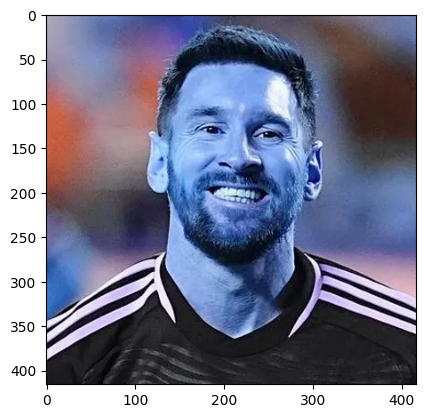

In [7]:
plt.imshow(img)

In [8]:
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray.shape

(416, 416)

In [9]:
gray

array([[177, 177, 176, ..., 140, 142, 141],
       [177, 178, 177, ..., 140, 141, 141],
       [177, 177, 177, ..., 140, 141, 141],
       ...,
       [ 29,  28,  24, ...,  18,  18,  18],
       [ 24,  25,  28, ...,  18,  18,  18],
       [ 21,  24,  29, ...,  18,  18,  18]], shape=(416, 416), dtype=uint8)

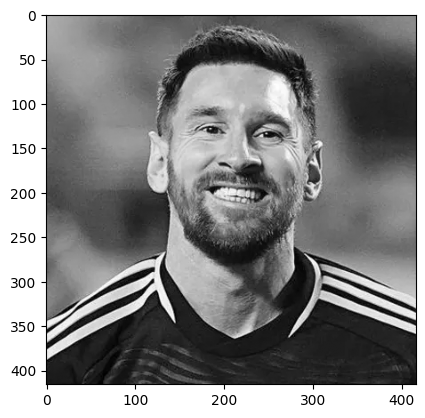

In [10]:
plt.imshow(gray,cmap='gray')

In [11]:
face_cascade = cv2.CascadeClassifier('./open cv/haarcascades/haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('./open cv/haarcascades/haarcascade_eye.xml')
faces = face_cascade.detectMultiScale(gray, 1.3, 5)
faces

array([[125,  58, 179, 179]], dtype=int32)

In [12]:
(x,y,w,h) = faces[0]
x,y,w,h

(np.int32(125), np.int32(58), np.int32(179), np.int32(179))

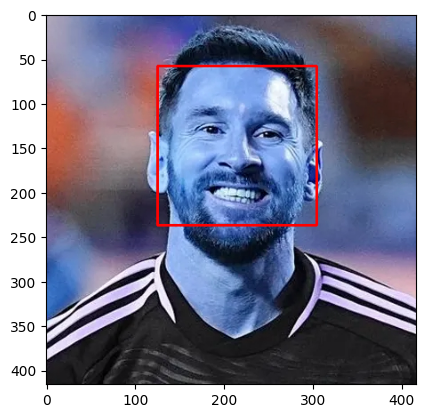

In [13]:
face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
plt.imshow(face_img)

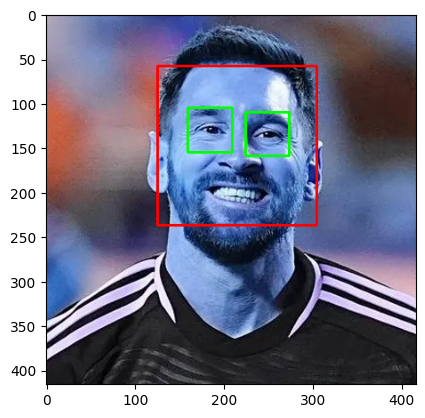

In [14]:
cv2.destroyAllWindows()
for (x,y,w,h) in faces:
    face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = face_img[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)
        

plt.figure()
plt.imshow(face_img, cmap='gray')
plt.show()

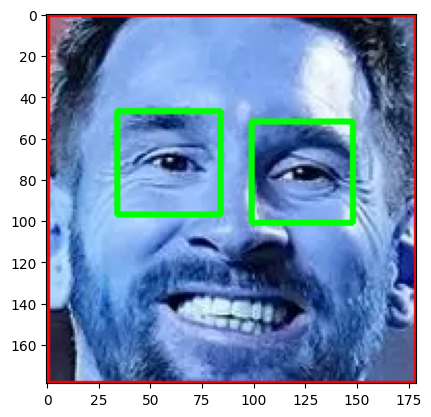

In [15]:
%matplotlib inline
plt.imshow(roi_color, cmap='gray')

In [16]:
cropped_img = np.array(roi_color)

In [17]:
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Image not found at {image_path}")
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray, scaleFactor=1.1, minNeighbors=10)

        if len(eyes) >= 2:
            return roi_color

    return None  


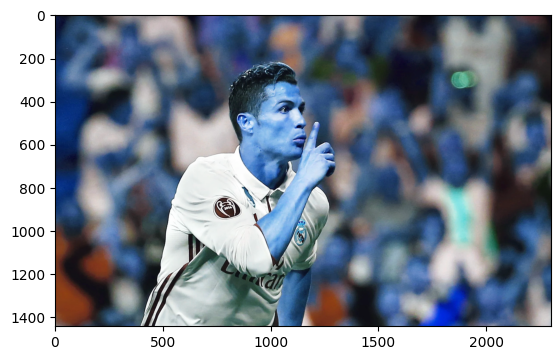

In [18]:
img1 = cv2.imread('./test/real.jpg')
plt.imshow(img1)

In [19]:
c = get_cropped_image_if_2_eyes('./test/real.jpg')
c

In [20]:
path_to_data = "./dataset/"
path_to_cr_data = "./dataset/cropped/"

In [21]:
import os
img_dirs = []
for entry in os.scandir(path_to_data):
    if entry.is_dir():
        img_dirs.append(entry.path)

In [22]:
img_dirs

['./dataset/cropped',
 './dataset/Jude Bellingham',
 './dataset/Lionel_Messi',
 './dataset/Mbappe',
 './dataset/Ronaldo']

In [23]:
import shutil
if os.path.exists(path_to_cr_data):
     shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

In [24]:

cropped_image_dir = []
footballer_filename = {}

for img_dir in img_dirs:
    footballer_name = os.path.basename(img_dir)
    print(footballer_name)

    count = 1  # reset per footballer

    for entry in os.scandir(img_dir):
        roi_color = get_cropped_image_if_2_eyes(entry.path)
        if roi_color is not None:
            cropped_folder = os.path.join(path_to_cr_data, footballer_name)
            os.makedirs(cropped_folder, exist_ok=True)

            cropped_name = f"{footballer_name}{count}.png"
            cropped_path = os.path.join(cropped_folder, cropped_name)

            cv2.imwrite(cropped_path, roi_color)

            # keep track of cropped image paths
            footballer_filename.setdefault(footballer_name, []).append(cropped_path)
            cropped_image_dir.append(cropped_path)  # optional: store actual file instead of folder

            print("Saved:", cropped_path)

            count += 1


cropped
Jude Bellingham
Saved: ./dataset/cropped/Jude Bellingham\Jude Bellingham1.png
Saved: ./dataset/cropped/Jude Bellingham\Jude Bellingham2.png
Saved: ./dataset/cropped/Jude Bellingham\Jude Bellingham3.png
Saved: ./dataset/cropped/Jude Bellingham\Jude Bellingham4.png
Saved: ./dataset/cropped/Jude Bellingham\Jude Bellingham5.png
Saved: ./dataset/cropped/Jude Bellingham\Jude Bellingham6.png
Saved: ./dataset/cropped/Jude Bellingham\Jude Bellingham7.png
Saved: ./dataset/cropped/Jude Bellingham\Jude Bellingham8.png
Saved: ./dataset/cropped/Jude Bellingham\Jude Bellingham9.png
Saved: ./dataset/cropped/Jude Bellingham\Jude Bellingham10.png
Saved: ./dataset/cropped/Jude Bellingham\Jude Bellingham11.png
Saved: ./dataset/cropped/Jude Bellingham\Jude Bellingham12.png
Saved: ./dataset/cropped/Jude Bellingham\Jude Bellingham13.png
Saved: ./dataset/cropped/Jude Bellingham\Jude Bellingham14.png
Saved: ./dataset/cropped/Jude Bellingham\Jude Bellingham15.png
Saved: ./dataset/cropped/Jude Bellingham

In [25]:
!pip install PyWavelets

Defaulting to user installation because normal site-packages is not writeable


In [26]:
import numpy as np
import pywt
import cv2    

def w2d(img, mode='haar', level=1):
    imArray = img
    #Datatype conversions
    #convert to grayscale
    imArray = cv2.cvtColor( imArray,cv2.COLOR_RGB2GRAY )
    #convert to float
    imArray =  np.float32(imArray)   
    imArray /= 255;
    # compute coefficients 
    coeffs=pywt.wavedec2(imArray, mode, level=level)

    #Process Coefficients
    coeffs_H=list(coeffs)  
    coeffs_H[0] *= 0;  

    # reconstruction
    imArray_H=pywt.waverec2(coeffs_H, mode);
    imArray_H *= 255;
    imArray_H =  np.uint8(imArray_H)

    return imArray_H

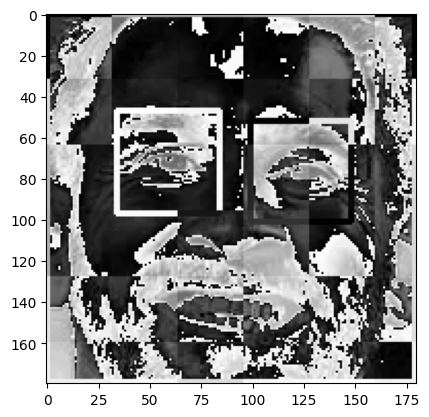

In [27]:
im_har = w2d(cropped_img,'db1',5)
plt.imshow(im_har, cmap='gray')

In [28]:
class_dict = {}
count = 0
for footballer_name in footballer_filename.keys():
    class_dict[footballer_name] = count
    count = count + 1
class_dict

{'Jude Bellingham': 0, 'Lionel_Messi': 1, 'Mbappe': 2, 'Ronaldo': 3}

In [29]:
X = []
y = []

for footballer, training_files in footballer_filename.items():
    for footballer_image in training_files:
        img = cv2.imread(footballer_image)
        if img is None:
            continue
        
        scaled = cv2.resize(img, (32, 32))
        img_hr = w2d(img, 'db1', 5)  
        scaled_hr = cv2.resize(img_hr, (32, 32))
        
        combined_list = np.concatenate((
            scaled.reshape(-1),      
            scaled_hr.reshape(-1)    
        ))
        
        X.append(combined_list)
        y.append(class_dict[footballer])  


In [28]:
len(X[0])

4096

In [39]:
X = np.array(X).reshape(len(X),4096).astype(float)
X.shape

(97, 4096)

In [40]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel = 'rbf', C = 10))])
pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)

0.64

In [41]:
print(classification_report(y_test, pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       0.67      0.50      0.57         8
           1       1.00      0.75      0.86         4
           2       0.54      0.88      0.67         8
           3       0.67      0.40      0.50         5

    accuracy                           0.64        25
   macro avg       0.72      0.63      0.65        25
weighted avg       0.68      0.64      0.63        25



In [42]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

In [43]:
model_params = {
    'svm': {
        'model': svm.SVC(gamma='auto', probability=True),
        'params' : {
            'svc__C': [1,10,100,1000],
            'svc__kernel': ['rbf','linear']
        }  
    },
    'random_forest': {
        'model': RandomForestClassifier(),
        'params' : {
            'randomforestclassifier__n_estimators': [1,5,10]
        }
    },
    'logistic_regression' : {
        'model': LogisticRegression(solver='liblinear', multi_class='auto'),
        'params': {
            'logisticregression__C': [1,5,10]
        }
    }
}


In [44]:
scores = []
best_estimators = {}
import pandas as pd
for algo, mp in model_params.items():
    pipe = make_pipeline(StandardScaler(), mp['model'])
    clf =  GridSearchCV(pipe, mp['params'], cv=5, return_train_score=False)
    clf.fit(X_train, y_train)
    scores.append({
        'model': algo,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
    best_estimators[algo] = clf.best_estimator_
    
df = pd.DataFrame(scores,columns=['model','best_score','best_params'])
df

C:\Users\vedic pundir\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\vedic pundir\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
C:\Users\vedic pundir\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this

,model,best_score,best_params
0,svm,0.640952,"{'svc__C': 1, 'svc__kernel': 'linear'}"
1,random_forest,0.401905,{'randomforestclassifier__n_estimators': 10}
2,logistic_regression,0.653333,{'logisticregression__C': 1}


In [45]:
 best_estimators

{'svm': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('svc',
                  SVC(C=1, gamma='auto', kernel='linear', probability=True))]),
 'random_forest': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('randomforestclassifier',
                  RandomForestClassifier(n_estimators=10))]),
 'logistic_regression': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('logisticregression',
                  LogisticRegression(C=1, multi_class='auto',
                                     solver='liblinear'))])}

In [46]:
best_estimators['svm'].score(X_test,y_test)

0.72

In [47]:
best_estimators['random_forest'].score(X_test,y_test)

0.44

In [48]:
best_estimators['svm'].score(X_test,y_test)

0.72

In [49]:
best_clf = best_estimators['logistic_regression']

In [51]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, best_clf.predict(X_test))
cm

array([[8, 0, 0, 0],
       [0, 3, 0, 1],
       [1, 0, 6, 1],
       [0, 0, 0, 5]])

In [52]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable


Text(95.72222222222221, 0.5, 'Truth')

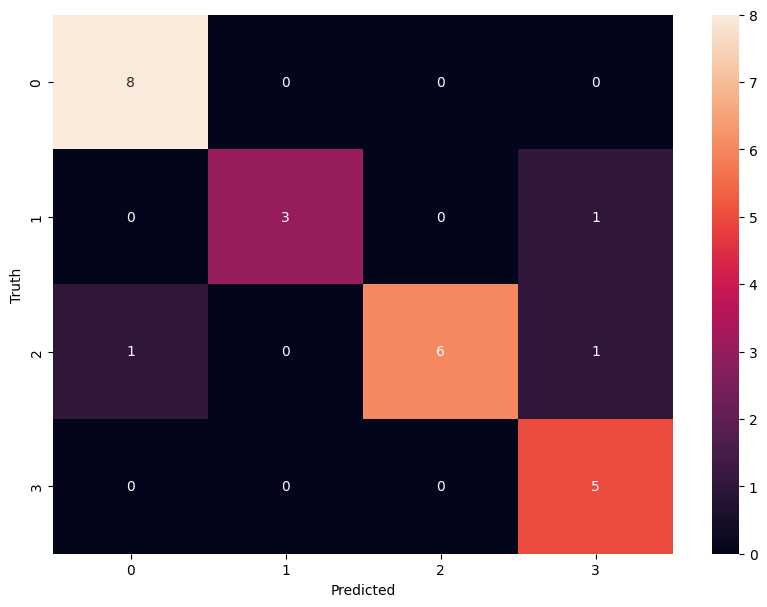

In [53]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [55]:
class_dict

{'Jude Bellingham': 0, 'Lionel_Messi': 1, 'Mbappe': 2, 'Ronaldo': 3}

In [56]:
!pip install joblib
import joblib 
# Save the model as a pickle in a file 
joblib.dump(best_clf, 'savedmodel.pkl')

Defaulting to user installation because normal site-packages is not writeable


['savedmodel.pkl']

In [57]:
import json
with open("class_dictionary.json","w") as f:
    f.write(json.dumps(class_dict))